# Gene lists comparison

## Preliminaries

In [1]:
import os
import scanpy as sc
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_venn 

In [2]:
data_folder = "data"
figure_folder = "figures"

In [3]:
sc.set_figure_params(frameon=False)
sc.settings.verbosity = 3

In [4]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = "none"

## Glial Progenitor Score

In [5]:
DCs = pd.read_csv(os.path.join(data_folder, "Couturier_at_al_Supp_Data_2.csv"),skiprows=1)
glial_progenitor_list = DCs["DC3 - low: glial; high: glial progenitor"].dropna().tolist()

In [6]:
len(glial_progenitor_list)

551

## SOX+ NES+ cells signature from bulk RNAseq

In [7]:
degs = pd.read_csv(os.path.join(data_folder, "deseq2_toptable.sox2_nes_positive_vs_negative.txt"), comment="#", sep="\t")

In [8]:
degs

,gene_name,baseMean,log2FoldChange,pvalue,padj,Significance,Geneid,Chr,Start,End,Strand,Length
0,ENSG00000287001,2102.840576,2.091563,1.278941e-07,0.001938,up,ENSG00000287001.4,chr19;chr19;chr19;chr19;chr19;chr19;chr19;chr1...,50095888;50095888;50096182;50110315;50121404;5...,50096310;50096306;50096310;50110847;50121552;5...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,3440
1,CHI3L1,6387.900812,2.162906,9.968581e-07,0.007553,up,ENSG00000133048.14,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,203178931;203178931;203178931;203178931;203178...,203179585;203179585;203179585;203179877;203179...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,3601
2,CENPF,21977.633821,1.520262,2.289139e-06,0.009243,up,ENSG00000117724.16,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,214603172;214603185;214603195;214603195;214603...,214603338;214603321;214603321;214603321;214603...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,12621
3,5_8S_rRNA.4,520.356402,-5.572463,2.439631e-06,0.009243,down,ENSG00000277739.1,chr21,8256781,8256933,+,153
4,TOP2A,7594.614299,1.877024,3.760961e-06,0.010398,up,ENSG00000131747.16,chr17;chr17;chr17;chr17;chr17;chr17;chr17;chr1...,40388525;40388525;40388525;40388526;40389516;4...,40389647;40389647;40389647;40388858;40389602;4...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,6374
...,...,...,...,...,...,...,...,...,...,...,...,...
20256,NUBPL,250.228120,-0.000248,9.998004e-01,0.999955,not_sign,ENSG00000151413.18,chr14;chr14;chr14;chr14;chr14;chr14;chr14;chr1...,31489956;31526052;31526155;31550771;31550771;3...,31490103;31526176;31526176;31550927;31550927;3...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,7768
20257,IL18BP,1536.517697,0.000104,9.998128e-01,0.999955,not_sign,ENSG00000137496.20,chr11;chr11;chr11;chr11;chr11;chr11;chr11;chr1...,71998613;71998882;71998892;71998900;71998909;7...,72000012;71999019;71999019;71999019;71999019;7...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,5851
20258,ADAM23,3077.015702,-0.000076,9.998229e-01,0.999955,not_sign,ENSG00000114948.14,chr2;chr2;chr2;chr2;chr2;chr2;chr2;chr2;chr2;c...,206443498;206443521;206443522;206443524;206443...,206444080;206444080;206444080;206444080;206444...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,6660
20259,TCEA3,446.329083,0.000082,9.999134e-01,0.999979,not_sign,ENSG00000204219.12,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,23370591;23370601;23376396;23380909;23380934;2...,23371624;23373130;23376490;23381474;23381474;2...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,7013


In [9]:
sox2_pos_nes_pos_signature = degs[(degs['log2FoldChange'] > 0) & (degs['padj'] < 0.1)].gene_name.tolist()

In [10]:
len(sox2_pos_nes_pos_signature)

36

## GSC-like tumor cell signature

Import signatures from Neftel 2019

In [11]:
degs = pd.read_excel(os.path.join(data_folder, "richards_2021_extended_data_S10.xlsx"), sheet_name="GSClikeTumour_DE", index_col=0)

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [12]:
degs

,X,p_val,avg_logFC,pct.1,pct.2,p_val_adj,log2FC,log10.adj.p
1,TUBB,0.000000e+00,1.045300,0.887,0.757,0.000000,1.508048,inf
2,GJA1,0.000000e+00,-1.114220,0.110,0.600,0.000000,-1.607480,inf
3,ANXA1,0.000000e+00,-1.129634,0.342,0.788,0.000000,-1.629717,inf
4,CLU,0.000000e+00,-1.179591,0.840,0.960,0.000000,-1.701791,inf
5,NTRK2,0.000000e+00,-1.257728,0.213,0.725,0.000000,-1.814519,inf
...,...,...,...,...,...,...,...,...
892,SPP1,9.643086e-08,0.371701,0.618,0.650,0.001956,0.536252,2.708545
893,2020-09-09 00:00:00,1.046819e-07,0.260374,0.458,0.472,0.002124,0.375640,2.672889
894,SCG3,1.056570e-07,0.278490,0.430,0.420,0.002144,0.401776,2.668862
895,HBB,1.804775e-07,-1.215912,0.120,0.088,0.003662,-1.754190,2.436338


In [13]:
gsclike_markers = degs[degs["log2FC"] > 1].X.tolist()

In [14]:
len(gsclike_markers)

32

## Venn diagrams

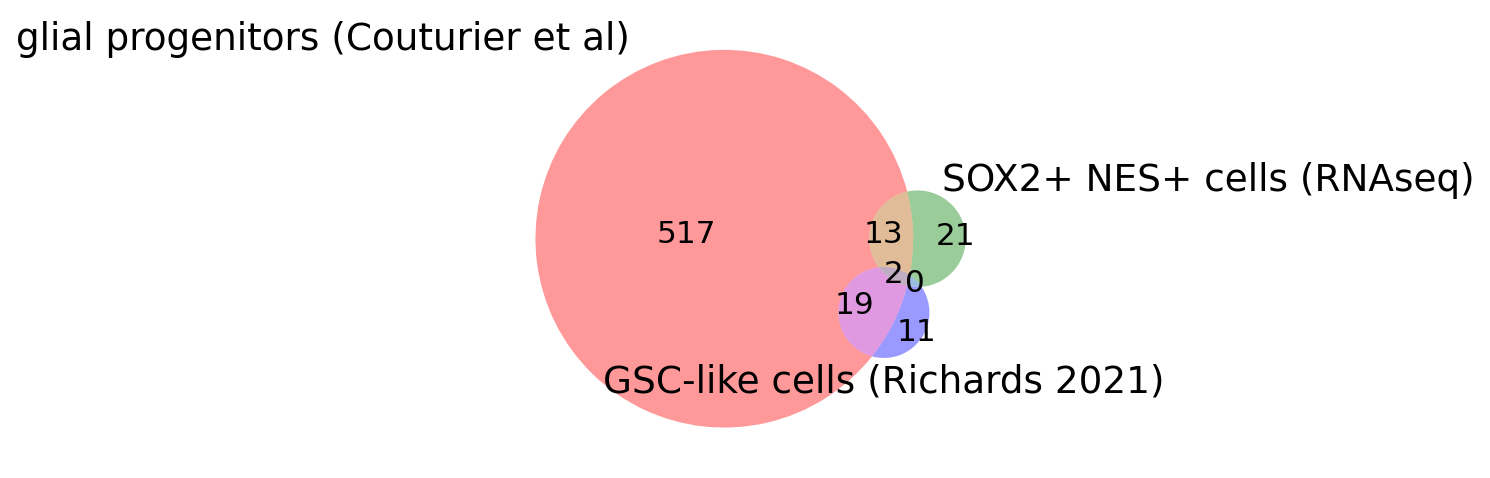

In [15]:
matplotlib_venn.venn3([set(glial_progenitor_list), set(sox2_pos_nes_pos_signature), set(gsclike_markers)], 
                      ["glial progenitors (Couturier et al)", "SOX2+ NES+ cells (RNAseq)", "GSC-like cells (Richards 2021)"])

In [16]:
with open(os.path.join(data_folder, "public_datasets_gene_lists.gmt"), "w") as f:

    line = "\t".join(["glial_progenitors_Couturier", "glial progenitors (Couturier et al)"] + sorted(glial_progenitor_list)) + "\n"
    f.write(line)

    line = "\t".join(["gsclike_cells_Richards", "GSC-like cells (Richards 2021)"] + sorted(gsclike_markers)) + "\n"
    f.write(line)
